Visual Comparison: Teacher vs Model Prediction

In [1]:
import sys
from pathlib import Path
root = Path.cwd()
if (root / 'qcgpt').exists():
    sys.path.insert(0, str(root))
elif (root.parent / 'qcgpt').exists():
    sys.path.insert(0, str(root.parent))


In [2]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qcgpt.gates import VOCAB, PAD_ID, BOS_CIRC_ID, EOS_CIRC_ID
from qcgpt.models.policy import CircuitPolicy
from qcgpt.data.dataset import SimplifiedCircuitDataset
from qcgpt.data.specs import build_spec_sequence_batch
from qcgpt.encoding import tokens_to_circuit
from qcgpt.evaluation.visualize import format_circuit
from qcgpt.evaluation.metrics import quantum_fidelity_from_spec, gate_count
from qcgpt.simulators.qiskit_sim import circuit_to_qiskit


C:\Users\CaioV\AppData\Roaming\Python\Python313\site-packages\torch\nn\modules\transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


Example 1
Teacher:
00: S q0
01: T q0
02: S q1
03: Y q1
04: X q1
05: T q1
06: T q1
07: CZ q0 q1
08: S q1
09: X q1
Predicted:
00: T q0
01: Z q1
02: X q1
03: S q1
04: CZ q0 q1
05: S q0
Fidelity teacher: 1.000 | Fidelity pred: 1.000


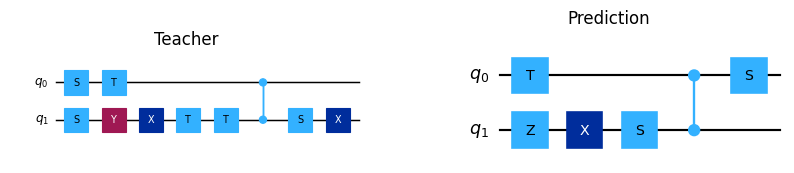

------------------------------------------------------------
Example 2
Teacher:
00: H q0
01: Z q0
02: S q0
03: T q1
04: H q1
05: Z q1
06: X q1
Predicted:
00: CX q1 q0
01: H q0
02: S q0
03: Z q0
04: Z q1
05: Z q1
06: T q1
07: X q1
08: H q1
Fidelity teacher: 1.000 | Fidelity pred: 0.500


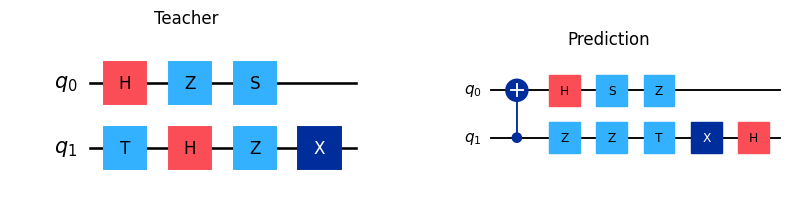

------------------------------------------------------------
Example 3
Teacher:
00: H q0
Predicted:
00: H q0
Fidelity teacher: 1.000 | Fidelity pred: 1.000


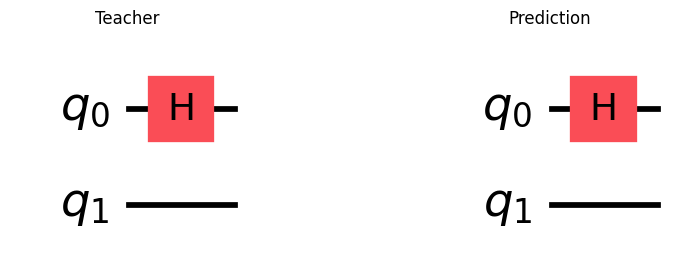

------------------------------------------------------------
Example 4
Teacher:
00: X q0
01: Y q0
02: S q0
03: X q0
04: Z q1
Predicted:
00: T q0
01: T q0
02: Z q0
03: Y q0
04: Z q0
05: Z q1
Fidelity teacher: 1.000 | Fidelity pred: 1.000


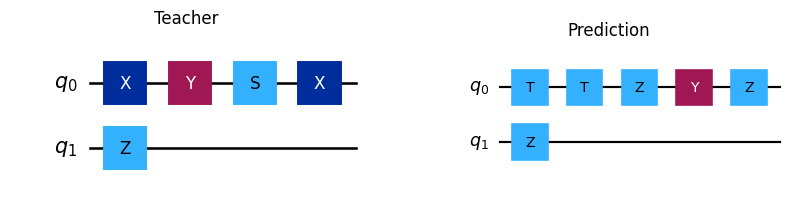

------------------------------------------------------------
Example 5
Teacher:
00: Y q0
Predicted:
00: Y q0
Fidelity teacher: 1.000 | Fidelity pred: 1.000


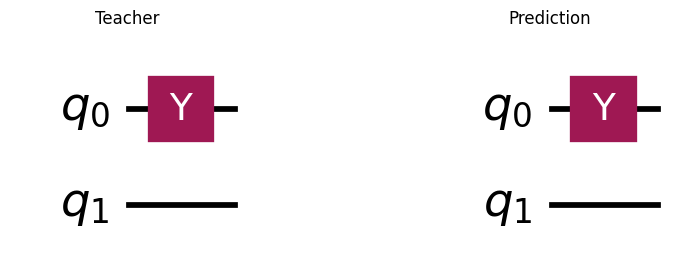

------------------------------------------------------------


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CircuitPolicy(vocab_size=len(VOCAB)).to(device)
ckpt_paths = [
    'checkpoints/supervised_best.pt',
    'checkpoints/supervised_final.pt',
    'checkpoints/supervised_current.pt',
]
for p in ckpt_paths:
    if os.path.exists(p):
        state = torch.load(p, map_location=device)
        model.load_state_dict(state['model_state_dict'])
        break
model.eval()
ds = SimplifiedCircuitDataset(num_samples=5, n_qubits=2, raw_max_depth=16)
items = [ds[i] for i in range(5)]
for idx, item in enumerate(items):
    teacher_circ = tokens_to_circuit(item['circ_tokens'].tolist())
    spec_tensor = item['spec_tensor'].numpy()
    spec_batch_np, spec_pad_mask_np = build_spec_sequence_batch([spec_tensor])
    spec_b = torch.tensor(spec_batch_np, dtype=torch.float32, device=device)
    pad_b = torch.tensor(spec_pad_mask_np, dtype=torch.bool, device=device)
    with torch.no_grad():
        seqs, logp = model.sample_circuit_tokens(spec_b, pad_b, BOS_CIRC_ID, EOS_CIRC_ID, max_len=64)
    seq = [t for t in seqs[0].tolist() if t != PAD_ID]
    pred_circ = tokens_to_circuit(seq)
    print(f'Example {idx+1}')
    print('Teacher:')
    print(format_circuit(teacher_circ))
    print('Predicted:')
    print(format_circuit(pred_circ))
    fid_teacher = quantum_fidelity_from_spec(spec_tensor, teacher_circ)
    fid_pred = quantum_fidelity_from_spec(spec_tensor, pred_circ)
    print(f'Fidelity teacher: {fid_teacher:.3f} | Fidelity pred: {fid_pred:.3f}')
    # Visualize side-by-side using Qiskit mpl drawer
    qc_teacher = circuit_to_qiskit(teacher_circ)
    qc_pred = circuit_to_qiskit(pred_circ)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].set_title('Teacher')
    qc_teacher.draw(output='mpl', ax=axes[0])
    axes[1].set_title('Prediction')
    qc_pred.draw(output='mpl', ax=axes[1])
    plt.show()
    print('-'*60)
